# YearPredictionMSD — Linear Regression CPU/GPU Benchmark

Uses the **full dataset** with the official split:

- 463,715 training rows
- 51,630 test rows
- 515,345 total rows
- 90 features

No sampling/subsampling.

Change only:

```python
DEVICE = "cpu"
```

or:

```python
DEVICE = "cuda"
```


## 1. Install and import

In [1]:

import subprocess, sys, importlib.util
if importlib.util.find_spec("codecarbon") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "codecarbon"])

import os, gc, copy, glob, math, time, random, zipfile, threading, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from codecarbon import EmissionsTracker

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 119.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.0 which is incompatible.


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Device switch

In [2]:

DEVICE = "cuda"   # change only to "cuda" for GPU run

DEVICE = DEVICE.lower().strip()
if DEVICE not in {"cpu", "cuda"}:
    raise ValueError('DEVICE must be "cpu" or "cuda".')
if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA selected but unavailable. Enable Kaggle GPU.")
print("Selected:", DEVICE.upper())


Selected: CUDA


## 3. Fixed configuration

In [3]:

SEED = 42

N_TRAIN = 463_715
N_TEST = 51_630
N_TOTAL = 515_345
N_FEATURES = 90

BATCH_SIZE = 1024
EPOCHS = 20
LEARNING_RATE = 1e-3
CARBON_MEASURE_SECS = 1

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


## 4. Load full YearPredictionMSD

In [4]:

def find_local_dataset():
    patterns = [
        "/kaggle/input/**/YearPredictionMSD.txt",
        "/kaggle/input/**/*YearPredictionMSD*.txt",
        "./data/**/YearPredictionMSD.txt",
    ]
    for pat in patterns:
        for p in glob.glob(pat, recursive=True):
            if os.path.isfile(p):
                return Path(p)
    return None

def get_dataset_path():
    local = find_local_dataset()
    if local is not None:
        print("Using local:", local)
        return local

    data_dir = Path("data")
    data_dir.mkdir(exist_ok=True)
    txt = data_dir / "YearPredictionMSD.txt"
    if txt.exists():
        return txt

    zpath = data_dir / "YearPredictionMSD.txt.zip"
    urls = [
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip",
        "https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip",
    ]

    last_error = None
    for url in urls:
        try:
            print("Downloading:", url)
            urllib.request.urlretrieve(url, zpath)
            with zipfile.ZipFile(zpath) as z:
                member = next(name for name in z.namelist() if name.endswith("YearPredictionMSD.txt"))
                with z.open(member) as src, open(txt, "wb") as dst:
                    dst.write(src.read())
            return txt
        except Exception as exc:
            print("Failed:", exc)
            last_error = exc

    raise RuntimeError("Could not obtain YearPredictionMSD.") from last_error

dataset_path = get_dataset_path()

data = pd.read_csv(dataset_path, header=None, dtype=np.float32)
print("Loaded:", data.shape)

if data.shape != (N_TOTAL, N_FEATURES + 1):
    raise ValueError(f"Expected {(N_TOTAL, N_FEATURES + 1)}, got {data.shape}")

y_all = data.iloc[:, 0].to_numpy(dtype=np.float32, copy=True)
X_all = data.iloc[:, 1:].to_numpy(dtype=np.float32, copy=True)

del data
gc.collect()


Downloading: https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Loaded: (515345, 91)


0

## 5. Official full split and preprocessing

In [5]:

X_train_raw = X_all[:N_TRAIN]
y_train_years = y_all[:N_TRAIN]

X_test_raw = X_all[N_TRAIN:]
y_test_years = y_all[N_TRAIN:]

assert len(X_train_raw) == N_TRAIN
assert len(X_test_raw) == N_TEST

prep_start = time.perf_counter()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

y_mean = float(y_train_years.mean())
y_std = float(y_train_years.std())

y_train = ((y_train_years - y_mean) / y_std).astype(np.float32)

preprocessing_time_s = time.perf_counter() - prep_start

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Preprocessing time (excluded):", preprocessing_time_s)


Train: (463715, 90)
Test: (51630, 90)
Preprocessing time (excluded): 0.5268868269999984


## 6. Full DataLoaders

In [6]:

train_dataset = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train).unsqueeze(1),
)

test_dataset = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test_years).unsqueeze(1),
)

def make_loaders(seed):
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=g,
        drop_last=False,
        num_workers=0,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=0,
    )

    return train_loader, test_loader

train_loader, test_loader = make_loaders(SEED)

print("Training rows:", len(train_dataset))
print("Test rows:", len(test_dataset))


Training rows: 463715
Test rows: 51630


## 7. Linear Regression model

In [7]:

class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(N_FEATURES, 1)

    def forward(self, x):
        return self.linear(x)

set_seed(SEED)

model = LinearRegressor()
INITIAL_STATE = copy.deepcopy(model.state_dict())
model = model.to(DEVICE)

parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Parameters:", f"{parameter_count:,}")
print("Device:", next(model.parameters()).device)


Parameters: 91
Device: cuda:0


## 8. CodeCarbon helpers

In [8]:

process = psutil.Process(os.getpid())

def sync():
    if DEVICE == "cuda":
        torch.cuda.synchronize()

class PeakMemory:
    def __init__(self):
        self.peak = 0
        self.stop_event = threading.Event()

    def _watch(self):
        while not self.stop_event.is_set():
            self.peak = max(self.peak, process.memory_info().rss)
            time.sleep(0.1)

    def start(self):
        self.peak = process.memory_info().rss
        self.stop_event.clear()
        self.thread = threading.Thread(target=self._watch, daemon=True)
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        self.thread.join(timeout=2)
        return self.peak / (1024 ** 2)

def make_tracker(name):
    kwargs = dict(
        project_name=name,
        measure_power_secs=CARBON_MEASURE_SECS,
        tracking_mode="process",
        gpu_ids=[0] if DEVICE == "cuda" else [],
        log_level="error",
    )
    try:
        return EmissionsTracker(output_methods=[], **kwargs)
    except TypeError:
        return EmissionsTracker(save_to_file=False, save_to_api=False, **kwargs)

def env_values(tracker):
    data = getattr(tracker, "final_emissions_data", None)

    def attr(name):
        if data is None:
            return np.nan
        value = getattr(data, name, np.nan)
        return np.nan if value is None else value

    return {
        "energy_kwh": attr("energy_consumed"),
        "co2_kg": attr("emissions"),
        "cpu_energy_kwh": attr("cpu_energy"),
        "gpu_energy_kwh": attr("gpu_energy"),
        "ram_energy_kwh": attr("ram_energy"),
        "country": getattr(data, "country_name", None) if data is not None else None,
    }


## 9. Warm-up

In [9]:

with torch.no_grad():
    x0, _ = next(iter(train_loader))
    _ = model(x0.to(DEVICE))
sync()

if DEVICE == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Warm-up complete.")


Warm-up complete.


## 10. Train

In [10]:

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

tracker = make_tracker(f"YearPredictionMSD-linear_regression-{DEVICE}-training")
memory = PeakMemory()

epoch_losses = []
epoch_times = []

tracker.start()
memory.start()
sync()

train_start = time.perf_counter()

for epoch in range(EPOCHS):
    model.train()
    epoch_start = time.perf_counter()

    total_loss = 0.0
    seen = 0

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        pred = model(x)
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        n = y.size(0)
        total_loss += loss.item() * n
        seen += n

    sync()

    epoch_time = time.perf_counter() - epoch_start
    epoch_loss = total_loss / seen

    epoch_losses.append(epoch_loss)
    epoch_times.append(epoch_time)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"normalized MSE={epoch_loss:.6f} | "
        f"time={epoch_time:.2f}s"
    )

sync()

training_time_s = time.perf_counter() - train_start
peak_process_ram_mb = memory.stop()

tracker.stop()
training_env = env_values(tracker)

peak_gpu_mb = np.nan
if DEVICE == "cuda":
    peak_gpu_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

training_throughput = (len(train_dataset) * EPOCHS) / training_time_s

print("Training time:", training_time_s)
print("Throughput:", training_throughput, "examples/s")
print("Energy kWh:", training_env["energy_kwh"])
print("CO2 kg:", training_env["co2_kg"])


[codecarbon WARNING @ 07:17:30] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/20 | normalized MSE=0.842591 | time=4.06s
Epoch 2/20 | normalized MSE=0.766699 | time=3.89s
Epoch 3/20 | normalized MSE=0.764378 | time=3.94s
Epoch 4/20 | normalized MSE=0.764162 | time=3.90s
Epoch 5/20 | normalized MSE=0.764007 | time=3.81s
Epoch 6/20 | normalized MSE=0.763822 | time=3.93s
Epoch 7/20 | normalized MSE=0.764026 | time=4.02s
Epoch 8/20 | normalized MSE=0.764221 | time=3.95s
Epoch 9/20 | normalized MSE=0.763962 | time=3.77s
Epoch 10/20 | normalized MSE=0.764024 | time=3.91s
Epoch 11/20 | normalized MSE=0.764075 | time=3.98s
Epoch 12/20 | normalized MSE=0.764000 | time=3.90s
Epoch 13/20 | normalized MSE=0.764082 | time=3.78s
Epoch 14/20 | normalized MSE=0.764067 | time=3.91s
Epoch 15/20 | normalized MSE=0.763987 | time=3.89s
Epoch 16/20 | normalized MSE=0.764039 | time=3.94s
Epoch 17/20 | normalized MSE=0.764045 | time=3.69s
Epoch 18/20 | normalized MSE=0.764031 | time=3.87s
Epoch 19/20 | normalized MSE=0.763988 | time=3.91s
Epoch 20/20 | normalized MSE=0.764018 | 

## 11. Full-test inference

In [11]:

@torch.no_grad()
def predict_test():
    model.eval()
    pred_all = []
    true_all = []

    for x, y in test_loader:
        x = x.to(DEVICE)

        pred_std = model(x)
        pred_year = pred_std * y_std + y_mean

        pred_all.append(pred_year.squeeze(1).cpu().numpy())
        true_all.append(y.squeeze(1).numpy())

    return np.concatenate(true_all), np.concatenate(pred_all)

with torch.no_grad():
    x0, _ = next(iter(test_loader))
    _ = model(x0.to(DEVICE))
sync()

inf_tracker = make_tracker(f"YearPredictionMSD-linear_regression-{DEVICE}-inference")
inf_tracker.start()

sync()
inf_start = time.perf_counter()

y_true, y_pred = predict_test()

sync()
inference_time_s = time.perf_counter() - inf_start

inf_tracker.stop()
inference_env = env_values(inf_tracker)

inference_throughput = len(test_dataset) / inference_time_s
latency_ms = inference_time_s / len(test_dataset) * 1000

print("Inference time:", inference_time_s)
print("Inference throughput:", inference_throughput)
print("Inference energy kWh:", inference_env["energy_kwh"])


Inference time: 0.33251450200003774
Inference throughput: 155271.42331973882
Inference energy kWh: 3.646616901335364e-06


## 12. Metrics

In [12]:

mse = mean_squared_error(y_true, y_pred)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
medae = median_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

metrics_df = pd.DataFrame([{
    "RMSE_years": rmse,
    "MAE_years": mae,
    "Median_AE_years": medae,
    "R2": r2,
}])

display(metrics_df.round(6))


,RMSE_years,MAE_years,Median_AE_years,R2
0,9.515184,6.81739,4.972595,0.231185


## 13. Training curve

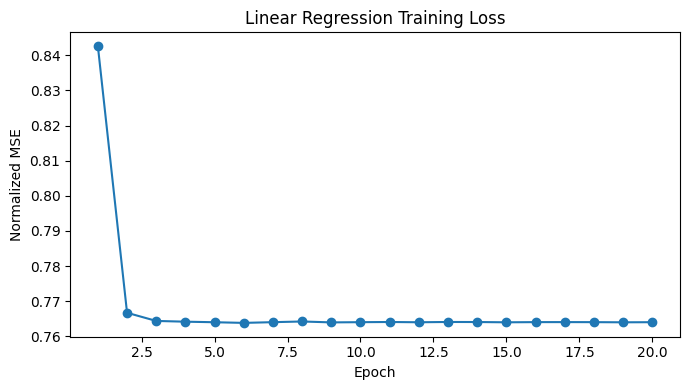

In [13]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, EPOCHS + 1), epoch_losses, marker="o")
ax.set_title("Linear Regression Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Normalized MSE")
fig.tight_layout()
plt.show()


## 14. Predicted vs actual

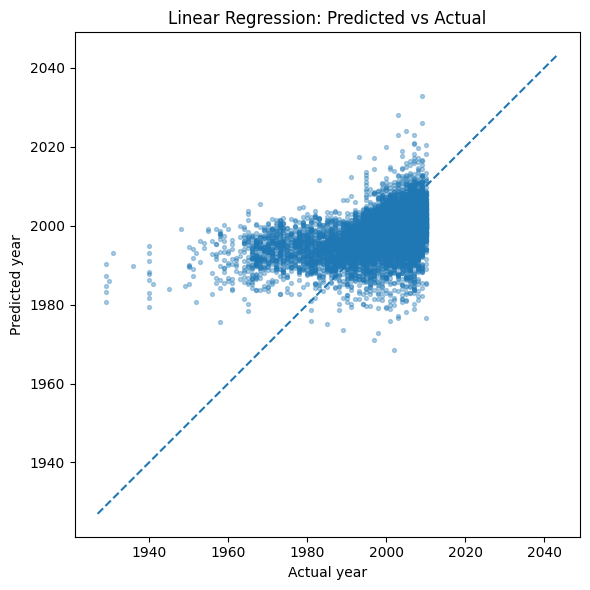

In [14]:

idx = np.linspace(0, len(y_true) - 1, min(10_000, len(y_true)), dtype=int)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true[idx], y_pred[idx], s=8, alpha=0.35)

low = min(float(y_true.min()), float(y_pred.min()))
high = max(float(y_true.max()), float(y_pred.max()))

ax.plot([low, high], [low, high], linestyle="--")
ax.set_title("Linear Regression: Predicted vs Actual")
ax.set_xlabel("Actual year")
ax.set_ylabel("Predicted year")
fig.tight_layout()
plt.show()


## 15. Final result and save

In [15]:

result = {
    "task": "Regression",
    "dataset": "YearPredictionMSD",
    "algorithm": "Linear Regression",
    "library": "PyTorch",
    "device": DEVICE,
    "seed": SEED,
    "full_train_rows": len(train_dataset),
    "full_test_rows": len(test_dataset),
    "features": N_FEATURES,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "trainable_parameters": parameter_count,
    "rmse_years": rmse,
    "mae_years": mae,
    "median_ae_years": medae,
    "r2": r2,
    "preprocessing_time_s": preprocessing_time_s,
    "training_time_s": training_time_s,
    "training_throughput_examples_s": training_throughput,
    "inference_time_s": inference_time_s,
    "inference_throughput_examples_s": inference_throughput,
    "latency_ms_per_example": latency_ms,
    "peak_process_ram_mb": peak_process_ram_mb,
    "peak_gpu_mb": peak_gpu_mb,
    "training_energy_kwh": training_env["energy_kwh"],
    "training_co2_kg": training_env["co2_kg"],
    "training_co2_g": training_env["co2_kg"] * 1000 if pd.notna(training_env["co2_kg"]) else np.nan,
    "training_cpu_energy_kwh": training_env["cpu_energy_kwh"],
    "training_gpu_energy_kwh": training_env["gpu_energy_kwh"],
    "training_ram_energy_kwh": training_env["ram_energy_kwh"],
    "inference_energy_kwh": inference_env["energy_kwh"],
    "inference_co2_kg": inference_env["co2_kg"],
    "carbon_country": training_env["country"],
}

result_df = pd.DataFrame([result])
display(result_df.round(6))

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
output_dir.mkdir(parents=True, exist_ok=True)

result_path = output_dir / f"linear_regression_yearprediction_{DEVICE}_result.csv"
result_df.to_csv(result_path, index=False)

print("Saved:", result_path)


,task,dataset,algorithm,library,device,seed,full_train_rows,full_test_rows,features,batch_size,...,peak_gpu_mb,training_energy_kwh,training_co2_kg,training_co2_g,training_cpu_energy_kwh,training_gpu_energy_kwh,training_ram_energy_kwh,inference_energy_kwh,inference_co2_kg,carbon_country
0,Regression,YearPredictionMSD,Linear Regression,PyTorch,cuda,42,463715,51630,90,1024,...,16.62793,0.000903,0.000258,0.257934,0.000088,0.000602,0.000214,0.000004,0.000001,United States


Saved: /kaggle/working/linear_regression_yearprediction_cuda_result.csv


## 16. Optional CPU/GPU comparison

In [16]:

output_dir = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")

cpu_path = output_dir / "linear_regression_yearprediction_cpu_result.csv"
gpu_path = output_dir / "linear_regression_yearprediction_cuda_result.csv"

if cpu_path.exists() and gpu_path.exists():
    cpu = pd.read_csv(cpu_path).iloc[0]
    gpu = pd.read_csv(gpu_path).iloc[0]

    comparison = pd.DataFrame([
        ["Training time (s)", cpu["training_time_s"], gpu["training_time_s"]],
        ["Inference time (s)", cpu["inference_time_s"], gpu["inference_time_s"]],
        ["Training energy (kWh)", cpu["training_energy_kwh"], gpu["training_energy_kwh"]],
        ["Training CO2e (g)", cpu["training_co2_g"], gpu["training_co2_g"]],
        ["RMSE (years)", cpu["rmse_years"], gpu["rmse_years"]],
        ["MAE (years)", cpu["mae_years"], gpu["mae_years"]],
        ["R2", cpu["r2"], gpu["r2"]],
    ], columns=["Metric", "CPU", "GPU"])

    display(comparison.round(6))

    print("GPU training speedup =", cpu["training_time_s"] / gpu["training_time_s"])
else:
    print("Run once with DEVICE='cpu' and once with DEVICE='cuda'.")


Run once with DEVICE='cpu' and once with DEVICE='cuda'.
